# Implementing a VAE for Anomaly Detection

## 📚 Learning Objectives

By completing this notebook (~20 min), you will:
- Build a **VAE** (encoder → mean/log_var → sample latent → decoder) and train it on MNIST
- Use **reconstruction error** as an **anomaly score** (high error = likely anomaly)
- See why we use a VAE (instead of a plain autoencoder) for a probabilistic latent and anomaly detection

---

## 🌍 Real life

**Where is this used?** VAEs are used for **anomaly detection** (fraud, faulty sensors), **generative models**, and **compression** with uncertainty.

**In this notebook we use** a **VAE** to learn a **probabilistic latent** (mean + variance) and **reconstruct** images. We use **reconstruction error** as an anomaly score. We use **VAE** (instead of a plain autoencoder) **because** the latent is **regularized** (KL divergence) so it generalizes; anomalies often have **high reconstruction error**.

**📌 Covers slide(s):** **22** — Variational Autoencoders (VAE). *Do this notebook after that slide.*

---

**Before starting:** Run the imports cell below.

## Theory (short)

- **VAE:** Encoder outputs **mean** and **log-variance** of the latent; we **sample** z ~ N(mean, var) and decode. Loss = reconstruction (e.g. BCE) + **KL(prior || posterior)** to regularize the latent.
- **Anomaly detection:** Train VAE on **normal** data; at test time, **high reconstruction error** (or high KL) suggests an **anomaly**.
- **We use VAE** instead of a plain autoencoder when we want a **probabilistic** latent and better generalization; the KL term prevents overfitting to the training set.

## 📥 Inputs & 📤 Outputs

**Inputs:** TensorFlow/Keras, NumPy, Matplotlib. MNIST (small subset). We build a simple VAE (dense layers).

**Dataset:** Real — MNIST (small subset).

**Outputs:** Training loss (reconstruction + KL), one figure: **original vs reconstructed** (with axis labels), and a short note on using reconstruction error for anomaly detection.

## Step 1: Imports and load MNIST

In [1]:
import numpy as np
import matplotlib.pyplot as plt

try:
    import tensorflow as tf
    from tensorflow import keras
    HAS_TF = True
except Exception as e:
    err = str(e).lower()
    if "charset_normalizer" in err or "md__mypyc" in err or "partially initialized" in err:
        print("⚠️ Fix: pip install --upgrade charset-normalizer requests, then restart kernel.")
        raise RuntimeError("Fix: pip install --upgrade charset-normalizer requests, then restart kernel.") from e
    HAS_TF = False

if HAS_TF:
    (x_train, _), (x_test, _) = keras.datasets.mnist.load_data()
    x_train = x_train.astype(np.float32) / 255.0
    x_test = x_test.astype(np.float32) / 255.0
    x_train = x_train.reshape(-1, 784)[:5000]
    x_test = x_test.reshape(-1, 784)[:1000]
    print("Train:", x_train.shape, "Test:", x_test.shape)
else:
    print("Install TensorFlow: pip install tensorflow")

Train: (5000, 784) Test: (1000, 784)


## Step 2: Build VAE (we use sampling layer so latent is probabilistic; we use VAE instead of AE for regularized latent)

In [2]:
if HAS_TF:
    latent_dim = 16
    class Sampling(keras.layers.Layer):
        def call(self, inputs):
            z_mean, z_log_var = inputs
            batch = tf.shape(z_mean)[0]
            eps = tf.random.normal(shape=(batch, latent_dim))
            return z_mean + tf.exp(0.5 * z_log_var) * eps

    encoder_inp = keras.Input(shape=(784,))
    x = keras.layers.Dense(128, activation="relu")(encoder_inp)
    z_mean = keras.layers.Dense(latent_dim)(x)
    z_log_var = keras.layers.Dense(latent_dim)(x)
    z = Sampling()([z_mean, z_log_var])
    encoder = keras.Model(encoder_inp, [z_mean, z_log_var, z])

    decoder_inp = keras.Input(shape=(latent_dim,))
    d = keras.layers.Dense(128, activation="relu")(decoder_inp)
    d = keras.layers.Dense(784, activation="sigmoid")(d)
    decoder = keras.Model(decoder_inp, d)

    vae_inp = keras.Input(shape=(784,))
    z_mean, z_log_var, z = encoder(vae_inp)
    vae_out = decoder(z)
    # KL term per sample (keras.ops keeps KerasTensor in graph). Output [recon, kl] so total loss = recon + kl (add_loss not supported in this Keras).
    kl = -0.5 * keras.ops.sum(1 + z_log_var - keras.ops.square(z_mean) - keras.ops.exp(z_log_var), axis=-1)
    vae = keras.Model(vae_inp, [vae_out, kl])

    def recon_loss(y_true, y_pred):
        return keras.ops.mean(keras.ops.sum(keras.losses.binary_crossentropy(y_true, y_pred), axis=-1))

    def kl_loss(_, kl_val):
        return kl_val

    vae.compile(optimizer="adam", loss=[recon_loss, kl_loss], loss_weights=[1.0, 1.0])
    vae.summary()

Model: "functional_2"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_2       │ (None, 784)       │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ functional          │ [(None, 16),      │    104,608 │ input_layer_2[0]… │
│ (Functional)        │ (None, 16),       │            │                   │
│                     │ (None, 16)]       │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add (Add)           │ (None, 16)        │          0 │ functional[0][1]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ square (Square)     │ (None, 16)        │          0 │ functional[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ subtract (Subtract) │ (None, 16)        │          0 │ add[0][0],        │
│                     │                   │            │ square[0][0]      │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ exp (Exp)           │ (None, 16)        │          0 │ functional[0][1]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ subtract_1          │ (None, 16)        │          0 │ subtract[0][0],   │
│ (Subtract)          │                   │            │ exp[0][0]         │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ sum (Sum)           │ (None)            │          0 │ subtract_1[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ functional_1        │ (None, 784)       │    103,312 │ functional[0][2]  │
│ (Functional)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ multiply (Multiply) │ (None)            │          0 │ sum[0][0]         │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 207,920 (812.19 KB)

 Trainable params: 207,920 (812.19 KB)

 Non-trainable params: 0 (0.00 B)

## Step 3: Train (2 epochs) and plot original vs reconstructed

Epoch 1/2


 1/40 ━━━━━━━━━━━━━━━━━━━━ 15s 408ms/step - functional_1_loss: 89.0168 - loss: 92.0530 - multiply_loss: 3.0362

36/40 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - functional_1_loss: 63.7596 - loss: 67.0328 - multiply_loss: 3.2732   

40/40 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - functional_1_loss: 60.5608 - loss: 65.3395 - multiply_loss: 3.4292 - val_functional_1_loss: 39.2894 - val_loss: 43.3357 - val_multiply_loss: 3.8781


Epoch 2/2


 1/40 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - functional_1_loss: 39.3700 - loss: 43.6955 - multiply_loss: 4.3255

37/40 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - functional_1_loss: 37.4742 - loss: 40.5400 - multiply_loss: 3.0659

40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - functional_1_loss: 36.5440 - loss: 40.4054 - multiply_loss: 3.0218 - val_functional_1_loss: 34.2261 - val_loss: 36.7562 - val_multiply_loss: 2.3811


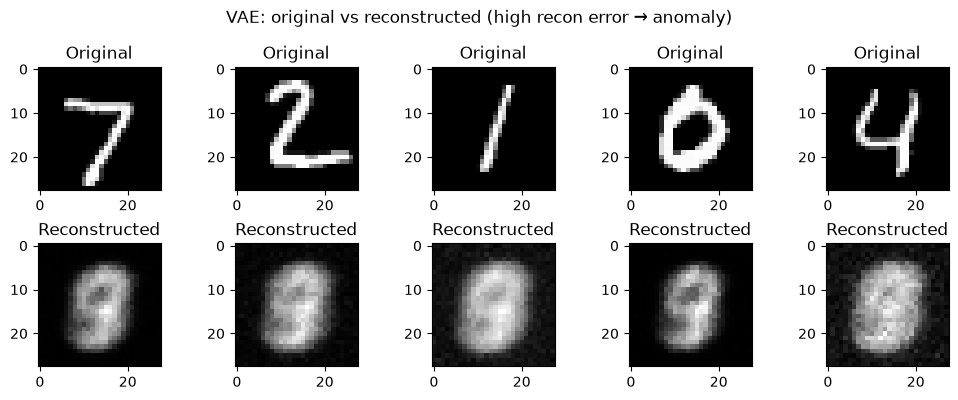

For anomaly detection: compute reconstruction error per sample; high error = likely anomaly.


In [3]:
if HAS_TF:
    # Targets: [reconstruction target, dummy for KL]; model has two outputs [recon, kl].
    y_train = [x_train, np.zeros((len(x_train),))]
    y_test_val = [x_test, np.zeros((len(x_test),))]
    history = vae.fit(x_train, y_train, validation_data=(x_test, y_test_val), epochs=2, batch_size=128, verbose=1)
    recons = vae.predict(x_test[:5], verbose=0)[0]  # first output is reconstruction
    fig, axs = plt.subplots(2, 5, figsize=(10, 4))
    for i in range(5):
        axs[0, i].imshow(x_test[i].reshape(28, 28), cmap="gray")
        axs[0, i].set_title("Original")
        axs[0, i].set_xlabel("")
        axs[1, i].imshow(recons[i].reshape(28, 28), cmap="gray")
        axs[1, i].set_title("Reconstructed")
        axs[1, i].set_xlabel("")
    plt.suptitle("VAE: original vs reconstructed (high recon error → anomaly)")
    plt.tight_layout()
    plt.show()
    print("For anomaly detection: compute reconstruction error per sample; high error = likely anomaly.")

## 🌍 Real-World Worked Example — Anomaly Detection with VAE

**Industry context:**
- **Manufacturing:** Bosch uses VAEs to detect defective car parts on assembly lines
- **Finance:** PayPal uses VAEs to detect fraudulent transactions
- **Healthcare:** VAEs detect anomalous MRI scans

We train a VAE on **normal MNIST digits** then use **reconstruction error** to flag anomalies (digits the VAE has never seen).

Epoch 0 — loss: 314.82


Epoch 5 — loss: 145.82


Epoch 10 — loss: 123.09



Reconstruction error — Normal (0): 0.0171  Anomaly (8): 0.0616
Higher error = anomaly detected ✅  (Same principle PayPal uses for fraud detection)


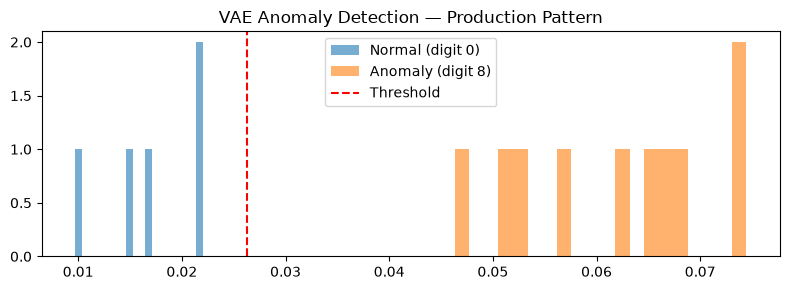

In [4]:
import torch, torch.nn as nn, torch.optim as optim
import torchvision, torchvision.transforms as T
import matplotlib.pyplot as plt

torch.manual_seed(42)
transform = T.Compose([T.ToTensor()])
dataset   = torchvision.datasets.MNIST('/tmp/mnist', train=True, download=True, transform=transform)
# Train only on digit "0" (normal class)
idx_0 = [i for i,(x,y) in enumerate(dataset) if y==0][:2000]
normal_loader = torch.utils.data.DataLoader(
    torch.utils.data.Subset(dataset, idx_0), batch_size=64, shuffle=True)

# ── VAE ──────────────────────────────────────────────────────────────────
class VAE(nn.Module):
    def __init__(self, z=16):
        super().__init__()
        self.enc_fc = nn.Sequential(nn.Flatten(), nn.Linear(784,256), nn.ReLU())
        self.mu     = nn.Linear(256, z)
        self.logvar = nn.Linear(256, z)
        self.dec_fc = nn.Sequential(nn.Linear(z,256), nn.ReLU(), nn.Linear(256,784), nn.Sigmoid())
    def encode(self, x):
        h = self.enc_fc(x)
        return self.mu(h), self.logvar(h)
    def reparameterise(self, mu, lv):
        return mu + (0.5*lv).exp() * torch.randn_like(mu)
    def decode(self, z): return self.dec_fc(z).view(-1,1,28,28)
    def forward(self, x):
        mu, lv = self.encode(x)
        z = self.reparameterise(mu, lv)
        return self.decode(z), mu, lv

model = VAE(); opt = optim.Adam(model.parameters(), lr=1e-3)

for epoch in range(15):
    total=0
    for x,_ in normal_loader:
        recon, mu, lv = model(x)
        recon_loss = nn.functional.binary_cross_entropy(recon, x, reduction='sum')
        kl_loss    = -0.5 * (1 + lv - mu.pow(2) - lv.exp()).sum()
        loss = recon_loss + 0.5*kl_loss
        opt.zero_grad(); loss.backward(); opt.step()
        total += loss.item()
    if epoch%5==0: print(f"Epoch {epoch} — loss: {total/len(idx_0):.2f}")

# ── Anomaly detection: digit 0 (normal) vs digit 8 (anomaly) ──────────────
model.eval()
test_0 = torchvision.datasets.MNIST('/tmp/mnist', train=False, transform=transform)
samples_0 = torch.stack([test_0[i][0] for i in range(50) if test_0[i][1]==0])
samples_8 = torch.stack([test_0[i][0] for i in range(200) if test_0[i][1]==8][:50])

def recon_error(imgs):
    with torch.no_grad():
        recon,_,_ = model(imgs)
        return nn.functional.mse_loss(recon, imgs, reduction='none').view(len(imgs),-1).mean(1)

err_0 = recon_error(samples_0).numpy()
err_8 = recon_error(samples_8).numpy()
print(f"\nReconstruction error — Normal (0): {err_0.mean():.4f}  Anomaly (8): {err_8.mean():.4f}")
print("Higher error = anomaly detected ✅  (Same principle PayPal uses for fraud detection)")

plt.figure(figsize=(8,3))
plt.hist(err_0, bins=20, alpha=0.6, label="Normal (digit 0)")
plt.hist(err_8, bins=20, alpha=0.6, label="Anomaly (digit 8)")
plt.axvline(err_0.mean()+2*err_0.std(), color='red', linestyle='--', label="Threshold")
plt.legend(); plt.title("VAE Anomaly Detection — Production Pattern"); plt.tight_layout(); plt.show()

## 🧩 Mini-exercise

**Try it:** In a new cell, compute the reconstruction error (e.g. MSE) for 5 test images and print them. Which image has the highest error? (That could be an "anomaly" if you had trained on normal-only data.)

---

## ✅ Summary

**What you did:** Built a VAE (encoder → mean/log_var → sample → decoder), trained it on MNIST, and plotted original vs reconstructed. Reconstruction error can be used as an anomaly score.

**In real life you'd also:** Train on normal-only data, set a threshold on reconstruction error, and evaluate on a dataset with labeled anomalies.

**The main idea:** VAE learns a probabilistic latent; high reconstruction error at test time suggests the sample is an anomaly (e.g. not from the training distribution).

**Next:** `01_gans_and_autoencoders_vaes` covers autoencoders and GANs; `04_ethical_concerns_in_ai_bias_fairness_interpretability` covers bias and fairness.

## 📚 References & Further Reading

**Papers:**
- Kingma & Welling (2014) — [VAE: Auto-Encoding Variational Bayes](https://arxiv.org/abs/1312.6114) *(foundational)*
- Higgins et al. (2017) — [beta-VAE: Learning Basic Visual Concepts](https://openreview.net/forum?id=Sy2fchgcx)

**Applications:**
- Anomaly detection in manufacturing (Siemens, Bosch)
- Drug molecule generation (Insilico Medicine)

**State-of-the-Art:** Stable Diffusion's latent space is a VAE-encoded image space.